In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('../data/loanDefaulter.csv')
print(df.head())

       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio  ... HasDependents  \
0               4         15.23        36      0.44  ...           Yes   
1               1          4.81        60      0.68  ...            No   
2               3         21.17        24      0.31  ...           Yes   
3               3          7.07        24      0.23  ...            No   
4               4          6.51        48      0.73  ...           Yes   

  LoanPurpose HasCoSigner Default Loan_to_Income Credit_per_Line  \
0       Other         Yes       0       0.588262          10

In [6]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [112]:
df.shape

(255347, 18)

In [113]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [114]:
df.drop_duplicates(inplace=True)

In [115]:
df.duplicated().sum()

np.int64(0)

In [116]:
for i in df.columns:
    print("Unique values in",i,":",df[i].nunique())

Unique values in LoanID : 255347
Unique values in Age : 52
Unique values in Income : 114620
Unique values in LoanAmount : 158729
Unique values in CreditScore : 550
Unique values in MonthsEmployed : 120
Unique values in NumCreditLines : 4
Unique values in InterestRate : 2301
Unique values in LoanTerm : 5
Unique values in DTIRatio : 81
Unique values in Education : 4
Unique values in EmploymentType : 4
Unique values in MaritalStatus : 3
Unique values in HasMortgage : 2
Unique values in HasDependents : 2
Unique values in LoanPurpose : 5
Unique values in HasCoSigner : 2
Unique values in Default : 2


In [117]:
for i in df.columns:
    print("Null values in",i,":",df[i].isnull().sum())    

Null values in LoanID : 0
Null values in Age : 0
Null values in Income : 0
Null values in LoanAmount : 0
Null values in CreditScore : 0
Null values in MonthsEmployed : 0
Null values in NumCreditLines : 0
Null values in InterestRate : 0
Null values in LoanTerm : 0
Null values in DTIRatio : 0
Null values in Education : 0
Null values in EmploymentType : 0
Null values in MaritalStatus : 0
Null values in HasMortgage : 0
Null values in HasDependents : 0
Null values in LoanPurpose : 0
Null values in HasCoSigner : 0
Null values in Default : 0


In [118]:
num_cols=[i for i in df.columns if df[i].dtype in ['int64','float64']]
cat_cols=[i for i in df.columns if df[i].dtype == 'object']

print("Numerical columns:",num_cols)
print("Categorical columns:",cat_cols)

Numerical columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']
Categorical columns: ['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


## Numerical Features

In [119]:
'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default'

('Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Default')

#### Feature 1: Loan Burden
#### Feature 2: Credit Strength
#### Feature 3: Employment Stability
#### Feature 4: Interest Burden
#### Feature 5: Risk Flags

In [120]:
df['Loan_to_Income'] = df['LoanAmount'] / df['Income']
df['Credit_per_Line'] = df['CreditScore'] / (df['NumCreditLines'] + 1)
df['Income_per_Employment'] = df['Income'] / (df['MonthsEmployed'] + 1)
df['Interest_Burden'] = df['InterestRate'] * df['LoanTerm']
df['High_DTI_Flag'] = (df['DTIRatio'] > 0.4).astype(int)
df['Low_Credit_Flag'] = (df['CreditScore'] < 600).astype(int)

## Categorical Features


In [121]:
df['HasCoSigner'].value_counts()

HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64

In [122]:
df['HasCoSigner']=df['HasCoSigner'].map({'No': 0, 'Yes': 1})

In [123]:
df['HasCoSigner'].value_counts()

HasCoSigner
1    127701
0    127646
Name: count, dtype: int64

In [124]:
df['LoanPurpose'].value_counts()

LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

In [ ]:
df['LoanPurpose'] = df['LoanPurpose'].map({
    'Home': 0,      
    'Auto': 1,       
    'Education': 1,  
    'Other': 2,      
    'Business': 3     
})

In [126]:
df['LoanPurpose'].value_counts()

LoanPurpose
1    101849
3     51298
0     51286
2     50914
Name: count, dtype: int64

In [127]:
df['HasDependents'].value_counts()

HasDependents
Yes    127742
No     127605
Name: count, dtype: int64

In [128]:
df['HasDependents']=df['HasDependents'].map({'No': 0, 'Yes': 1})

In [129]:
df['HasMortgage'].value_counts()

HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64

In [130]:
df['HasMortgage']=df['HasMortgage'].map({'No': 0, 'Yes': 1})

In [131]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

In [132]:
mapping_martial_status={
    "Single":0,
    "Married":1,
    "Divorced":0
}
df['MaritalStatus']=df['MaritalStatus'].map(mapping_martial_status)

In [133]:
df['EmploymentType'].value_counts()

EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

In [ ]:
df['EmploymentType'] = df['EmploymentType'].map({
    'Full-time': 0,
    'Self-employed': 1,
    'Part-time': 2,
    'Unemployed': 3
})

In [135]:
df['Education'].value_counts()

Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

In [136]:
mapping_education={
    "High School":1,
    "Bachelor's":2,
    "Master's":3,
    "PhD":4
}
df['Education']=df['Education'].map(mapping_education)

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   LoanID                 255347 non-null  object 
 1   Age                    255347 non-null  int64  
 2   Income                 255347 non-null  int64  
 3   LoanAmount             255347 non-null  int64  
 4   CreditScore            255347 non-null  int64  
 5   MonthsEmployed         255347 non-null  int64  
 6   NumCreditLines         255347 non-null  int64  
 7   InterestRate           255347 non-null  float64
 8   LoanTerm               255347 non-null  int64  
 9   DTIRatio               255347 non-null  float64
 10  Education              255347 non-null  int64  
 11  EmploymentType         255347 non-null  int64  
 12  MaritalStatus          255347 non-null  int64  
 13  HasMortgage            255347 non-null  int64  
 14  HasDependents          255347 non-nu

In [138]:
df.drop(['LoanID'], axis=1, inplace=True)

Text(0.5, 1.0, 'Correlation Heatmap')

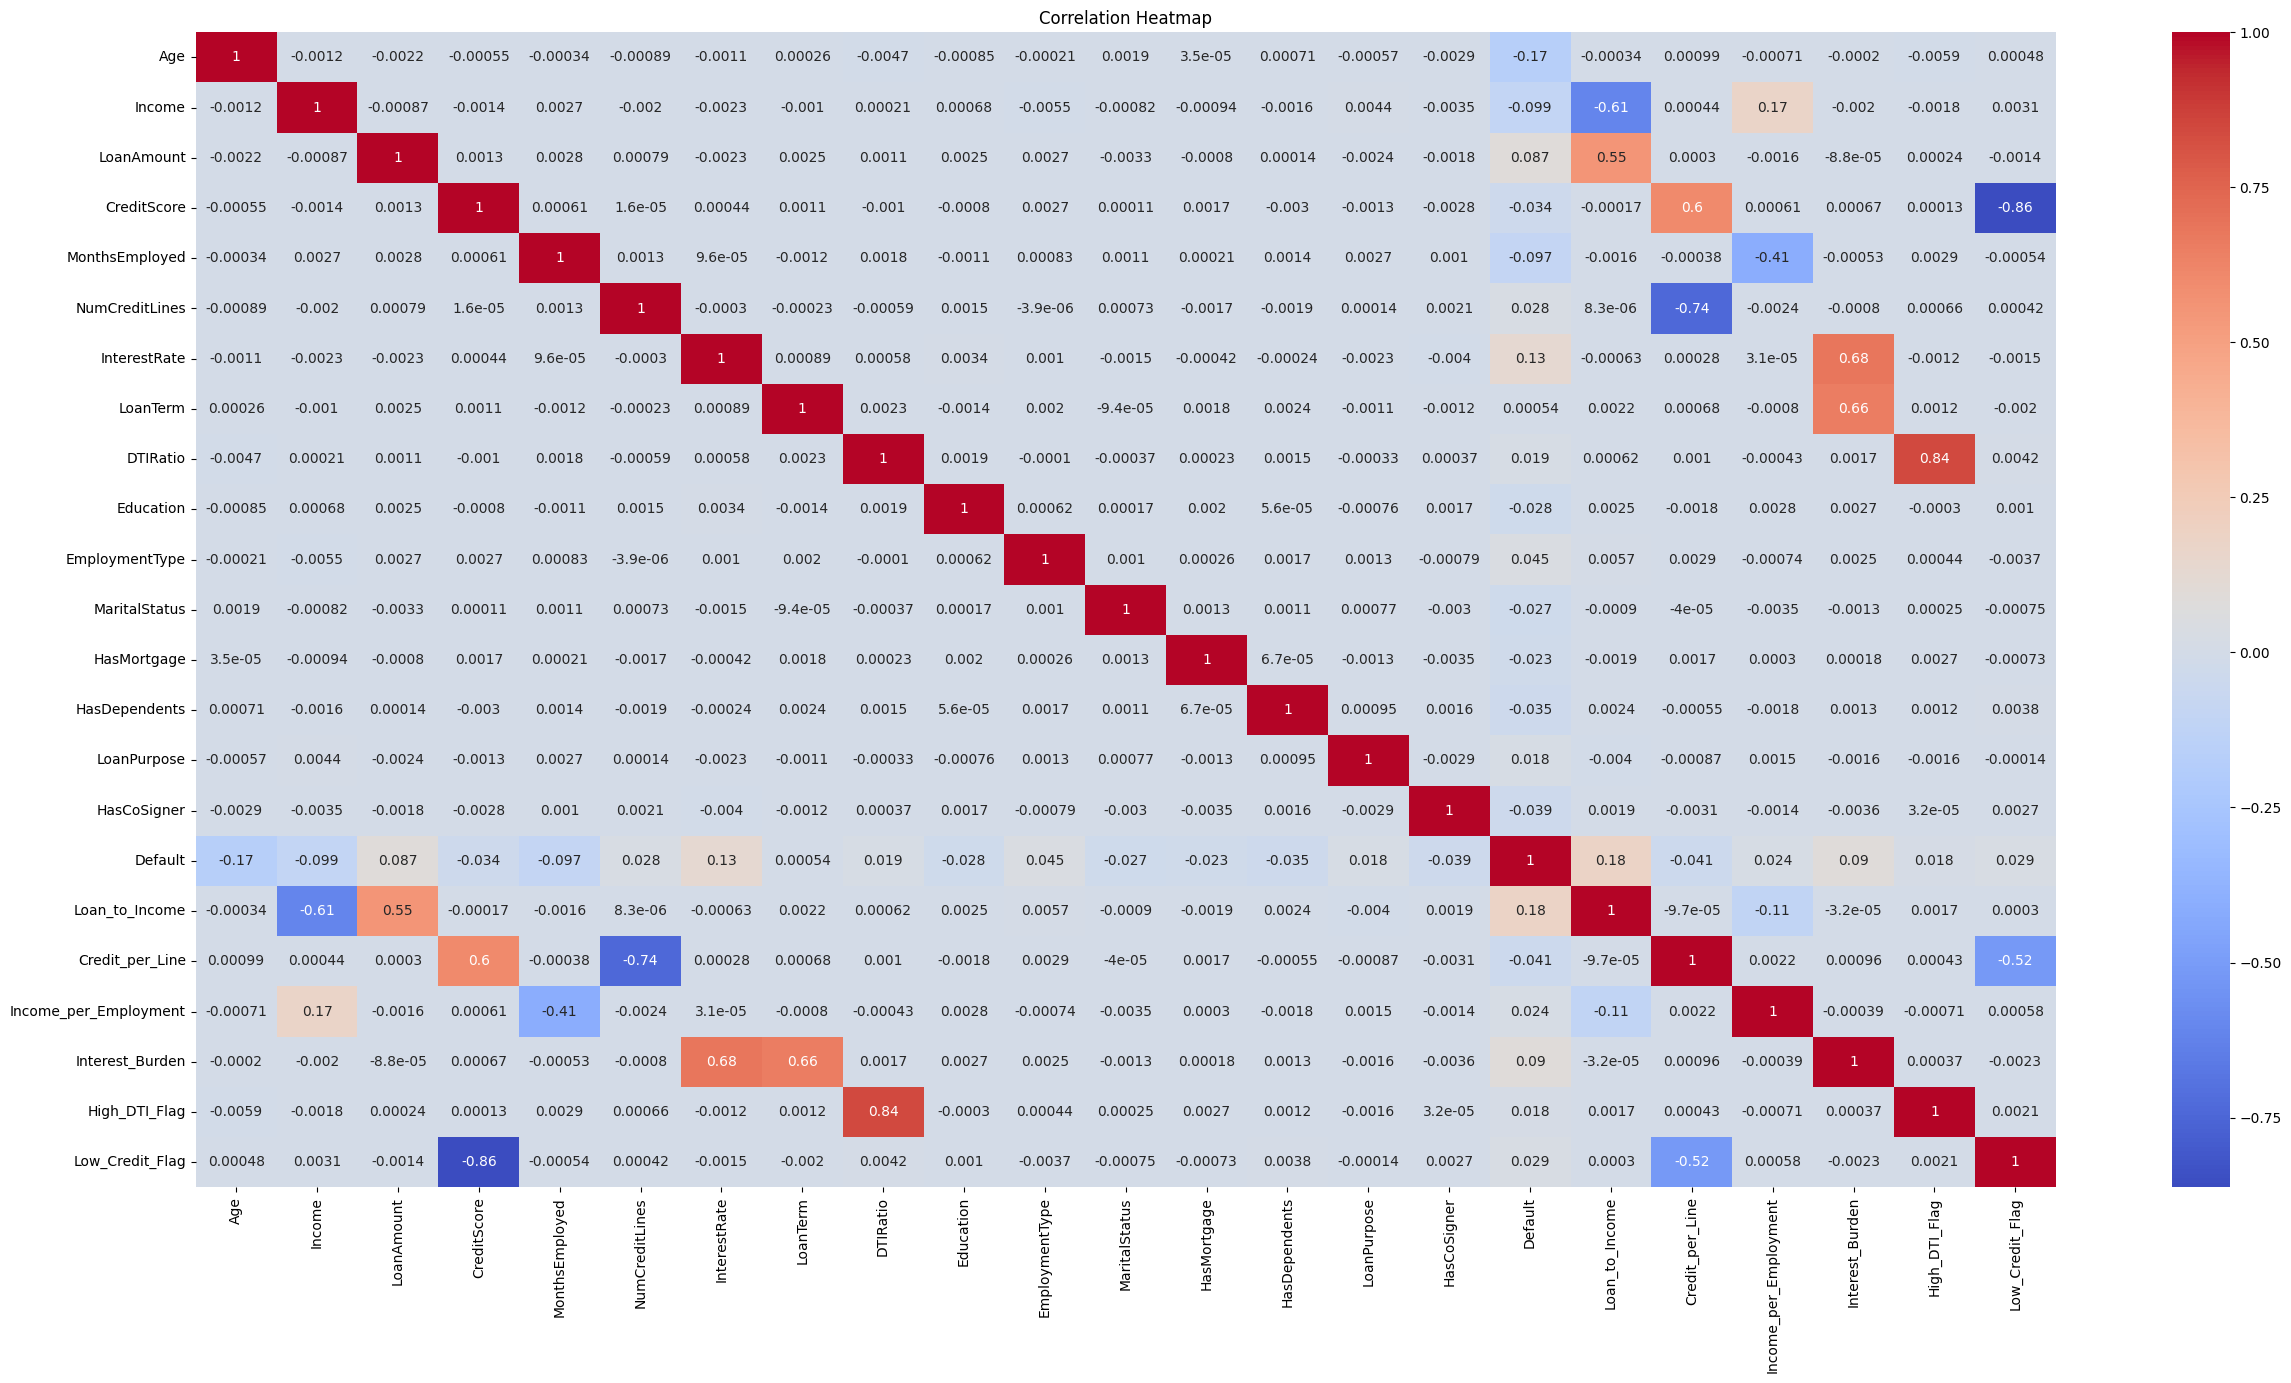

In [145]:
plt.figure(figsize=(30,15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

In [146]:
df.to_csv('../data/processed_loanDefaulter.csv', index=False)